In [35]:
# imports

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

import requests

# ML regression method (curve approximation of frontier)
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

import seaborn as sns

## Step 1: Choose an ETF with a minimum of 100 assets

In [36]:
# ETF selection
our_etf = ["QQQ"]

## Step 2: Identify the assets that constitute your chosen ETF


In [37]:
url = "https://companiesmarketcap.com/invesco-qqq-trust/holdings/"

# 1. Define a standard browser header to mask the Python automation signature
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36',
    'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,*/*;q=0.8',
    'Accept-Language': 'en-US,en;q=0.5'
}

try:
    # 2. Safely grab the webpage HTML content using the headers
    response = requests.get(url, headers=headers)
    response.raise_for_status()  # Check if the connection successfully returned HTTP 200
    
    # 3. Hand the raw text over to Pandas to parse out the tables
    tables = pd.read_html(response.text)
    qqq_holdings_df = tables[0]
    
    # 4. Clean column whitespaces
    qqq_holdings_df.columns = [col.strip() for col in qqq_holdings_df.columns]
    
    print(f"Bypass successful! Retrieved {len(qqq_holdings_df)} QQQ holdings.\n")
    print(qqq_holdings_df.head(15))

except Exception as e:
    print(f"Connection failed: {e}")

Bypass successful! Retrieved 104 QQQ holdings.

   Weight %                        Name Ticker  Shares Held
0     8.55%                 NVIDIA Corp   NVDA  189224642.0
1     7.41%                   Apple Inc   AAPL  114322359.0
2     5.09%              Microsoft Corp   MSFT   57823516.0
3     4.67%              Amazon.com Inc   AMZN   83593093.0
4     3.81%       Micron Technology Inc     MU   24195717.0
5     3.65%                Alphabet Inc  GOOGL   45336048.0
6     3.48%                   Tesla Inc   TSLA   38865773.0
7     3.44%  Advanced Micro Devices Inc    AMD   35049831.0
8     3.37%                Alphabet Inc   GOOG   42345847.0
9     3.21%                Broadcom Inc   AVGO   36920406.0
10    2.94%          Meta Platforms Inc   META   22966760.0
11    2.70%                  Intel Corp   INTC  107380235.0
12    2.66%                 Walmart Inc    WMT  105063614.0
13    2.15%           Cisco Systems Inc   CSCO   84913019.0
14    2.06%       Costco Wholesale Corp   COST    95

C:\Users\alesu\AppData\Local\Temp\ipykernel_20644\2858492097.py:16: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


In [38]:
qqq_holdings_df

,Weight %,Name,Ticker,Shares Held
0,8.55%,NVIDIA Corp,NVDA,1.892246e+08
1,7.41%,Apple Inc,AAPL,1.143224e+08
2,5.09%,Microsoft Corp,MSFT,5.782352e+07
3,4.67%,Amazon.com Inc,AMZN,8.359309e+07
4,3.81%,Micron Technology Inc,MU,2.419572e+07
...,...,...,...,...
99,0.10%,Insmed Inc,INSM,4.645058e+06
100,0.08%,Charter Communications Inc,CHTR,2.728913e+06
101,0.08%,CASH & EQUIVALENTS,USD,3.862027e+08
102,0.08%,CME E-Mini NASDAQ 100 Index Future,NQM6,6.500000e+02


## Step 3: Retrieve historical data for your chosen ETF and each asset


In [39]:
price_data = yf.download(our_etf + [str(qqq) for qqq in qqq_holdings_df["Ticker"].tolist()], start="2019-01-01", end="2026-01-01")["Close"]

[                       0%                       ]

[**********************87%*****************      ]  91 of 105 completed$NQM6: possibly delisted; no timezone found
[*********************100%***********************]  105 of 105 completed

1 Failed download:
['NQM6']: possibly delisted; no timezone found


In [40]:
price_data.head()

Ticker,AAPL,ABNB,ADBE,ADI,ADP,ADSK,AEP,ALNY,AMAT,AMD,...,TXN,USD,VRSK,VRTX,WBD,WDAY,WDC,WMT,XEL,ZS
Date,,,,,,,,,,,,,,,,,,,,,
2019-01-02,37.469208,NaN,224.570007,75.352364,111.297523,128.960007,56.125061,72.760002,30.988682,18.830000,...,76.536209,1.844634,103.579880,164.080002,25.830000,159.740005,27.329102,27.913778,38.741749,39.810001
2019-01-03,33.736992,NaN,215.699997,70.800690,107.936546,121.849998,55.994236,73.209999,29.193039,17.049999,...,72.022629,1.627870,100.414803,163.729996,25.680000,154.020004,25.464783,27.770231,38.589096,39.320000
2019-01-04,35.177197,NaN,226.190002,72.519630,112.238274,128.279999,56.509773,75.199997,31.192314,19.000000,...,75.280228,1.775025,104.847832,172.699997,26.139999,163.350006,26.543371,27.943684,38.966702,41.770000
2019-01-07,35.098915,NaN,229.259995,72.975670,111.631058,132.720001,56.194286,81.779999,31.747654,20.570000,...,76.576714,1.837917,104.952675,175.850006,26.530001,163.500000,27.486244,28.272642,38.797989,43.560001
2019-01-08,35.767998,NaN,232.679993,74.756012,112.289589,133.869995,56.886806,85.339996,30.461094,20.750000,...,76.479492,1.819599,105.886955,178.190002,27.240000,166.949997,27.221958,28.470018,39.247910,43.980000


In [41]:
# dropping unnecessary columns
# `ABNB` is a recent addition to the QQQ holdings, but it has very limited historical data, so we will drop it for now
price_data = price_data.drop(columns=["NAN", "USD", "ABNB"])
price_data.head()

Ticker,AAPL,ADBE,ADI,ADP,ADSK,AEP,ALNY,AMAT,AMD,AMGN,...,TTWO,TXN,VRSK,VRTX,WBD,WDAY,WDC,WMT,XEL,ZS
Date,,,,,,,,,,,,,,,,,,,,,
2019-01-02,37.469208,224.570007,75.352364,111.297523,128.960007,56.125061,72.760002,30.988682,18.830000,152.609985,...,104.010002,76.536209,103.579880,164.080002,25.830000,159.740005,27.329102,27.913778,38.741749,39.810001
2019-01-03,33.736992,215.699997,70.800690,107.936546,121.849998,55.994236,73.209999,29.193039,17.049999,150.287872,...,99.150002,72.022629,100.414803,163.729996,25.680000,154.020004,25.464783,27.770231,38.589096,39.320000
2019-01-04,35.177197,226.190002,72.519630,112.238274,128.279999,56.509773,75.199997,31.192314,19.000000,155.425262,...,101.699997,75.280228,104.847832,172.699997,26.139999,163.350006,26.543371,27.943684,38.966702,41.770000
2019-01-07,35.098915,229.259995,72.975670,111.631058,132.720001,56.194286,81.779999,31.747654,20.570000,157.516769,...,104.410004,76.576714,104.952675,175.850006,26.530001,163.500000,27.486244,28.272642,38.797989,43.560001
2019-01-08,35.767998,232.679993,74.756012,112.289589,133.869995,56.886806,85.339996,30.461094,20.750000,159.536713,...,107.919998,76.479492,105.886955,178.190002,27.240000,166.949997,27.221958,28.470018,39.247910,43.980000


In [42]:
# volume data
# Source: https://algotrading101.com/learn/yfinance-guide/
volume_data = yf.download(our_etf + [str(qqq) for qqq in qqq_holdings_df["Ticker"].tolist()], start="2019-01-01", end="2026-01-01")["Volume"]

[**********************87%*****************      ]  91 of 105 completed$NQM6: possibly delisted; no timezone found
[*********************100%***********************]  105 of 105 completed

1 Failed download:
['NQM6']: possibly delisted; no timezone found


In [43]:
volume_data = volume_data.drop(columns=["NAN", "NQM6", "USD", "ABNB"])
volume_data.head()

Ticker,AAPL,ADBE,ADI,ADP,ADSK,AEP,ALNY,AMAT,AMD,AMGN,...,TTWO,TXN,VRSK,VRTX,WBD,WDAY,WDC,WMT,XEL,ZS
Date,,,,,,,,,,,,,,,,,,,,,
2019-01-02,148158800,2784100,2523900,2190100,1517500,2679600,773400,11106300,87148700,3009100,...,1947400,6478800,770500,1465400,4595500,1796500,8447620,24458100,4476100,1280700
2019-01-03,365248800,3663500,4376600,3854000,2564700,3063500,645400,21580700,117277600,3973900,...,2301100,11667500,1102000,1690900,4947900,1828800,10233934,24831900,5287600,974800
2019-01-04,234428400,4043400,3470000,2161300,2480600,2857500,855800,15631800,111878600,4193400,...,3610800,7707600,811300,1874500,3856100,3077700,8378427,24087300,5535600,1782700
2019-01-07,219111200,3638500,2656300,3455800,1634600,3218400,1156900,13868800,107157000,3032500,...,2501900,5023900,801700,1294600,4022900,3294200,7895135,23369100,4208100,2211000
2019-01-08,164101200,3685900,3993500,2275600,1324800,3605700,995900,12485300,121271000,3290300,...,2402200,5863500,668500,1653200,3447900,2146600,10188555,21602700,3128300,1568600


In [44]:
# further data cleaning: dropping rows with missing values
price_data.shape
price_data.index.min(), price_data.index.max()
price_data.isna().sum().sort_values(ascending=False).head(20)
price_data.columns.tolist()

volume_data.shape
volume_data.index.min(), volume_data.index.max()
volume_data.isna().sum().sort_values(ascending=False).head(20)
volume_data.columns.tolist()

['AAPL',
 'ADBE',
 'ADI',
 'ADP',
 'ADSK',
 'AEP',
 'ALNY',
 'AMAT',
 'AMD',
 'AMGN',
 'AMZN',
 'APP',
 'ARM',
 'ASML',
 'AVGO',
 'AXON',
 'BKNG',
 'BKR',
 'CCEP',
 'CDNS',
 'CEG',
 'CHTR',
 'CMCSA',
 'COST',
 'CPRT',
 'CRWD',
 'CSCO',
 'CSX',
 'CTAS',
 'CTSH',
 'DASH',
 'DDOG',
 'DXCM',
 'EA',
 'EXC',
 'FANG',
 'FAST',
 'FER',
 'FTNT',
 'GEHC',
 'GILD',
 'GOOG',
 'GOOGL',
 'HON',
 'IDXX',
 'INSM',
 'INTC',
 'INTU',
 'ISRG',
 'KDP',
 'KHC',
 'KLAC',
 'LIN',
 'LITE',
 'LRCX',
 'MAR',
 'MCHP',
 'MDLZ',
 'MELI',
 'META',
 'MNST',
 'MPWR',
 'MRVL',
 'MSFT',
 'MSTR',
 'MU',
 'NFLX',
 'NVDA',
 'NXPI',
 'ODFL',
 'ORLY',
 'PANW',
 'PAYX',
 'PCAR',
 'PDD',
 'PEP',
 'PLTR',
 'PYPL',
 'QCOM',
 'QQQ',
 'REGN',
 'ROP',
 'ROST',
 'SBUX',
 'SHOP',
 'SNDK',
 'SNPS',
 'STX',
 'TMUS',
 'TRI',
 'TSLA',
 'TTWO',
 'TXN',
 'VRSK',
 'VRTX',
 'WBD',
 'WDAY',
 'WDC',
 'WMT',
 'XEL',
 'ZS']

## Step 4: Calculate the Barry Cox price momentum factors for each asset in your ETF


#### Slope of 52 Week Trend Line

In [45]:
# shift prices back by 20 days
lagged_prices = price_data.shift(20)

def calculate_trend_slope(window_prices):
    """
    Calculates normalized slope of a price trend line.
    window_prices should contain about 252 daily prices.
    """

    y = window_prices.dropna().values

    if len(y) < 252:
        return np.nan

    x = np.arange(len(y))

    slope, intercept = np.polyfit(x, y, 1)

    normalized_slope = slope / np.mean(y)

    return normalized_slope

In [46]:
trend_52w = lagged_prices.rolling(window=252).apply(calculate_trend_slope, raw=False)

In [47]:
trend_52w.iloc[268: 280]

Ticker,AAPL,ADBE,ADI,ADP,ADSK,AEP,ALNY,AMAT,AMD,AMGN,...,TTWO,TXN,VRSK,VRTX,WBD,WDAY,WDC,WMT,XEL,ZS
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-30,0.002179,0.000813,0.000701,0.000725,0.000290,0.000920,0.001062,0.002149,0.002435,0.000990,...,0.001329,0.001049,0.001058,0.000532,0.000372,-0.000486,0.001369,0.001168,0.001003,-0.000513
2020-01-31,0.002192,0.000811,0.000690,0.000714,0.000289,0.000910,0.001080,0.002150,0.002450,0.001008,...,0.001331,0.001042,0.001041,0.000538,0.000371,-0.000509,0.001372,0.001163,0.000991,-0.000567
2020-02-03,0.002195,0.000806,0.000673,0.000699,0.000282,0.000899,0.001099,0.002144,0.002457,0.001024,...,0.001327,0.001028,0.001022,0.000543,0.000370,-0.000534,0.001368,0.001156,0.000979,-0.000620
2020-02-04,0.002202,0.000804,0.000657,0.000688,0.000279,0.000890,0.001120,0.002141,0.002469,0.001044,...,0.001328,0.001017,0.001007,0.000556,0.000369,-0.000553,0.001364,0.001150,0.000967,-0.000669
2020-02-05,0.002207,0.000803,0.000643,0.000675,0.000279,0.000880,0.001147,0.002141,0.002485,0.001064,...,0.001332,0.001009,0.000992,0.000570,0.000370,-0.000571,0.001369,0.001143,0.000954,-0.000715
2020-02-06,0.002215,0.000805,0.000631,0.000662,0.000281,0.000870,0.001178,0.002138,0.002500,0.001085,...,0.001341,0.001000,0.000979,0.000589,0.000373,-0.000584,0.001375,0.001137,0.000942,-0.000756


In [48]:
# resample to monthly frequency by taking the last value of each month
monthly_trend_52w = trend_52w.resample("M").last()

monthly_trend_52w.tail(5)

Ticker,AAPL,ADBE,ADI,ADP,ADSK,AEP,ALNY,AMAT,AMD,AMGN,...,TTWO,TXN,VRSK,VRTX,WBD,WDAY,WDC,WMT,XEL,ZS
Date,,,,,,,,,,,,,,,,,,,,,
2025-08-31,-0.000502,-0.001819,0.000047,0.000625,0.000423,0.000502,0.000637,-0.000609,-0.000951,-0.000375,...,0.002088,-0.000220,0.000648,-0.000112,0.001462,-0.000052,0.000787,0.001121,0.000681,0.002246
2025-09-30,-0.000477,-0.001834,0.000213,0.000428,0.000184,0.000644,0.001676,-0.000393,-0.000136,-0.000228,...,0.001861,-0.000107,0.000365,-0.000342,0.001399,-0.000393,0.001537,0.000872,0.000571,0.002355
2025-10-31,-0.000248,-0.001652,0.000502,0.000198,0.000216,0.000769,0.002536,-0.000001,0.000642,-0.000054,...,0.001713,-0.000056,-0.000006,-0.000559,0.002194,-0.000469,0.003103,0.000753,0.000601,0.002281
2025-11-30,0.000054,-0.001604,0.000685,0.000008,0.000229,0.000918,0.003160,0.000720,0.002280,0.000151,...,0.001531,-0.000091,-0.000417,-0.000600,0.002733,-0.000569,0.004343,0.000666,0.000714,0.002342
2025-12-31,0.000450,-0.001477,0.000794,-0.000303,0.000311,0.001049,0.003358,0.001409,0.003463,0.000524,...,0.001295,-0.000134,-0.000864,-0.000539,0.003708,-0.000640,0.005841,0.000579,0.000886,0.002262


#### Percent Above 260 Day Low

In [49]:
low_260 = lagged_prices.rolling(window=260).min()

pct_above_260_low = (lagged_prices - low_260) / low_260

In [50]:
pct_above_260_low.tail(5)

Ticker,AAPL,ADBE,ADI,ADP,ADSK,AEP,ALNY,AMAT,AMD,AMGN,...,TTWO,TXN,VRSK,VRTX,WBD,WDAY,WDC,WMT,XEL,ZS
Date,,,,,,,,,,,,,,,,,,,,,
2025-12-24,0.611861,0.022887,0.544160,0.029110,0.232750,0.393014,0.916013,0.924571,1.635597,0.362053,...,0.361558,0.138632,0.072212,0.172641,1.985696,0.110325,4.104153,0.314454,0.299946,0.658728
2025-12-26,0.615237,0.016389,0.580310,0.021160,0.261849,0.406076,0.984308,0.984183,1.739292,0.375869,...,0.371636,0.163830,0.076394,0.179053,2.105331,0.023139,4.180678,0.340252,0.313852,0.442549
2025-12-29,0.622802,0.024744,0.625773,0.025054,0.270055,0.418106,1.011546,1.002281,1.781358,0.379422,...,0.385373,0.184382,0.082067,0.182981,2.120936,0.024469,4.364270,0.357573,0.327759,0.439858
2025-12-30,0.647536,0.033451,0.632942,0.027222,0.277508,0.380755,1.026391,1.022125,1.809871,0.347598,...,0.403783,0.183608,0.076971,0.161128,2.104031,0.013684,4.371167,0.370104,0.289273,0.392798
2025-12-31,0.665518,0.033323,0.672523,0.032603,0.298987,0.366089,1.072619,1.106106,1.752078,0.351072,...,0.381950,0.233582,0.081010,0.181726,2.189857,0.012306,4.254574,0.380914,0.278116,0.383638


In [51]:
monthly_pct_above_260_low = pct_above_260_low.resample("M").last()

#### 4/52 Week Price Oscillator

In [52]:
ma_4w = lagged_prices.rolling(window=20).mean()
ma_52w = lagged_prices.rolling(window=252).mean()

price_oscillator_4w_52w = ((ma_4w - ma_52w) / ma_52w)

In [53]:
# monthly
monthly_price_oscillator_4w_52w = price_oscillator_4w_52w.resample("M").last()

#### 39 Week Return

In [54]:
return_39w = (lagged_prices/lagged_prices.shift(195)) - 1
monthly_return_39w = return_39w.resample("M").last()

#### 51 week Volume Price trend

In [55]:
lagged_volume = volume_data.shift(20)

daily_returns = lagged_prices.pct_change()

daily_vpt = lagged_volume * daily_returns

vpt_51w = daily_vpt.rolling(window=252).sum()

monthly_vpt_51w = vpt_51w.resample("M").last()

C:\Users\alesu\AppData\Local\Temp\ipykernel_20644\3021685840.py:3: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  daily_returns = lagged_prices.pct_change()


## Step 5: Using the price momentum factors, calculate the monthly z-factor score for each asset


In [56]:
# what we have got so far
#  - monthly_trend_52w - Slope of 52 Week Trend Line
#  - monthly_pct_above_260_low - Percentage above 260 Week Low
#  - monthly_price_oscillator_4w_52w - Price Oscillator between 4 Week and 52 Week Moving Averages
#  - monthly_return_39w - Return over the past 39 Weeks
#  - monthly_vpt_51w - Volume Price Trend over the past 51 Weeks

#### z-score calculation

In [57]:
# for each month, compare every stock against all other stocks
def cross_sectional_zscore(factor_data):
    return factor_data.sub(factor_data.mean(axis=1), axis=0).div(
        factor_data.std(axis=1), axis=0)


In [58]:
# removing `QQQ` from the factor dataframes, since it is not a stock but an ETF
monthly_trend_52w = monthly_trend_52w.drop(columns=["QQQ"])
monthly_pct_above_260_low = monthly_pct_above_260_low.drop(columns=["QQQ"])
monthly_price_oscillator_4w_52w = monthly_price_oscillator_4w_52w.drop(columns=["QQQ"])
monthly_return_39w = monthly_return_39w.drop(columns=["QQQ"])  
monthly_vpt_51w = monthly_vpt_51w.drop(columns=["QQQ"])

# z-score normalization for each factor
z_trend_52w = cross_sectional_zscore(monthly_trend_52w)
z_pct_above_260_low = cross_sectional_zscore(monthly_pct_above_260_low)
z_price_oscillator_4w_52w = cross_sectional_zscore(monthly_price_oscillator_4w_52w)
z_return_39w = cross_sectional_zscore(monthly_return_39w)
z_vpt_51w = cross_sectional_zscore(monthly_vpt_51w)

combined_z_score = (
    z_trend_52w +
    z_pct_above_260_low +
    z_price_oscillator_4w_52w +
    z_return_39w +
    z_vpt_51w
) / 5



In [59]:
combined_z_score.tail()

Ticker,AAPL,ADBE,ADI,ADP,ADSK,AEP,ALNY,AMAT,AMD,AMGN,...,TTWO,TXN,VRSK,VRTX,WBD,WDAY,WDC,WMT,XEL,ZS
Date,,,,,,,,,,,,,,,,,,,,,
2025-08-31,-0.722435,-1.220547,-0.286919,-0.262392,-0.272353,-0.153436,0.285640,-0.404574,0.193608,-0.530748,...,0.474875,-0.416124,-0.325507,-0.504630,1.051392,-0.605998,0.779890,0.075021,-0.105698,0.779546
2025-09-30,-0.397279,-1.261023,-0.060554,-0.339825,-0.313391,-0.064896,1.316193,-0.595406,0.372935,-0.472735,...,0.381717,-0.379493,-0.539550,-0.817212,0.606446,-0.722320,1.254884,-0.020718,-0.196147,0.620701
2025-10-31,-0.266755,-1.061028,-0.152259,-0.500121,-0.302002,-0.145372,0.994516,-0.116211,0.291497,-0.445188,...,0.304915,-0.526260,-0.680268,-0.728507,2.045680,-0.689947,2.538503,-0.198550,-0.151349,0.567092
2025-11-30,-0.067708,-1.005692,-0.234177,-0.621509,-0.399541,-0.056152,0.871750,0.087941,1.868703,-0.405179,...,0.155182,-0.666713,-0.814184,-0.663917,2.292982,-0.652945,2.559915,-0.235737,-0.093786,0.557542
2025-12-31,0.046171,-0.875272,-0.097759,-0.648654,-0.326805,-0.094422,0.708829,0.363785,1.621028,-0.174502,...,-0.111834,-0.558174,-0.779347,-0.568364,2.359085,-0.659045,2.836486,-0.180941,-0.152181,0.083179


Based on the factor-correlation matrix:
- Return_39W is highly correlated with Trend_52W and Oscillator_4W_52W
- VPT_51W is the least redundant factor

## Step 6: Identify long and short baskets (10 to 15 assets in each) using calculated z-factors


#### Ranking Stocks

In [60]:
long_basket = combined_z_score.apply(
    lambda row: row.nlargest(15).index.tolist(),
    axis=1
)

short_basket = combined_z_score.apply(
    lambda row: row.nsmallest(15).index.tolist(),
    axis=1
)

## Step 7: Create a backtest to validate performance of your algorithm based on monthly restructuring over the previous 5 years.

#### create monthly stock returns

In [61]:
monthly_prices = price_data.resample("M").last()

monthly_returns = monthly_prices.pct_change()

etf_returns = monthly_returns["QQQ"]
monthly_returns = monthly_returns.drop(columns=["QQQ"])

C:\Users\alesu\AppData\Local\Temp\ipykernel_20644\3938471227.py:3: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  monthly_returns = monthly_prices.pct_change()


#### shift returns backward for next-month performance

In [62]:
next_month_returns = monthly_returns.shift(-1)
next_month_etf_returns = etf_returns.shift(-1)

#### back test look

In [63]:
backtest_results = []

num_stocks = 15

for date in combined_z_score.index:
    scores = combined_z_score.loc[date].dropna()
    
    if len(scores) < num_stocks * 2:
        continue
    
    long_tickers = scores.nlargest(num_stocks).index
    short_tickers = scores.nsmallest(num_stocks).index
    
    if date not in next_month_returns.index:
        continue
    
    returns = next_month_returns.loc[date]
    
    long_return = returns[long_tickers].mean()
    short_return = returns[short_tickers].mean()
    
    portfolio_return = long_return - short_return
    
    etf_return = next_month_etf_returns.loc[date]
    
    backtest_results.append({
        "Date": date,
        "Long Return": long_return,
        "Short Return": short_return,
        "Portfolio Return": portfolio_return,
        "ETF Return": etf_return,
        "Long Tickers": list(long_tickers),
        "Short Tickers": list(short_tickers)
    })

In [64]:
backtest_df = pd.DataFrame(backtest_results)
backtest_df = backtest_df.set_index("Date")

In [65]:
backtest_df.head()

,Long Return,Short Return,Portfolio Return,ETF Return,Long Tickers,Short Tickers
Date,,,,,,
2020-02-29,-0.100170,-0.119937,0.019766,-0.072858,"[TSLA, SHOP, NVDA, AMD, DXCM, AAPL, LRCX, CPRT...","[FANG, INSM, ZS, CSCO, CTSH, KHC, NFLX, BKR, W..."
2020-03-31,0.196786,0.200529,-0.003743,0.149738,"[TSLA, NVDA, DXCM, SHOP, AMD, LITE, LRCX, AAPL...","[FANG, ZS, CSCO, BKR, WDAY, KHC, PANW, EXC, CT..."
2020-04-30,0.137351,0.058699,0.078652,0.066009,"[TSLA, NVDA, DXCM, AMD, PDD, REGN, SHOP, ALNY,...","[FANG, BKR, MAR, WDAY, INSM, CSCO, WBD, CTSH, ..."
2020-05-31,0.103725,-0.007370,0.111095,0.062867,"[TSLA, NVDA, DXCM, SHOP, PDD, AMD, REGN, ALNY,...","[FANG, BKR, MAR, WDAY, WBD, CCEP, CSCO, BKNG, ..."
2020-06-30,0.105822,0.025538,0.080284,0.073465,"[TSLA, NVDA, DXCM, PDD, SHOP, REGN, AMD, ALNY,...","[FANG, CCEP, WBD, MAR, BKR, EXC, BKNG, CTSH, S..."


#### Calculate cumulative returns

In [66]:
backtest_df["Cumulative Portfolio Return"] = (
    1 + backtest_df["Portfolio Return"]
).cumprod() - 1

In [67]:
backtest_df["Cumulative ETF Return"] = (
    1 + backtest_df["ETF Return"]
).cumprod() - 1

In [68]:
backtest_df[["Long Return", "Short Return", "Portfolio Return", "ETF Return"]].head()

,Long Return,Short Return,Portfolio Return,ETF Return
Date,,,,
2020-02-29,-0.100170,-0.119937,0.019766,-0.072858
2020-03-31,0.196786,0.200529,-0.003743,0.149738
2020-04-30,0.137351,0.058699,0.078652,0.066009
2020-05-31,0.103725,-0.007370,0.111095,0.062867
2020-06-30,0.105822,0.025538,0.080284,0.073465


In [69]:
backtest_df[["Portfolio Return", "ETF Return"]].describe()

,Portfolio Return,ETF Return
count,70.000000,70.000000
mean,0.010507,0.018004
std,0.079077,0.059505
min,-0.235194,-0.135957
25%,-0.022929,-0.015802
50%,0.011207,0.019080
75%,0.057202,0.060913
max,0.224089,0.149738


## Step 8: Chart:
### 1. Monthly portfolio return bar chart (pos/neg coloring) vs ETF


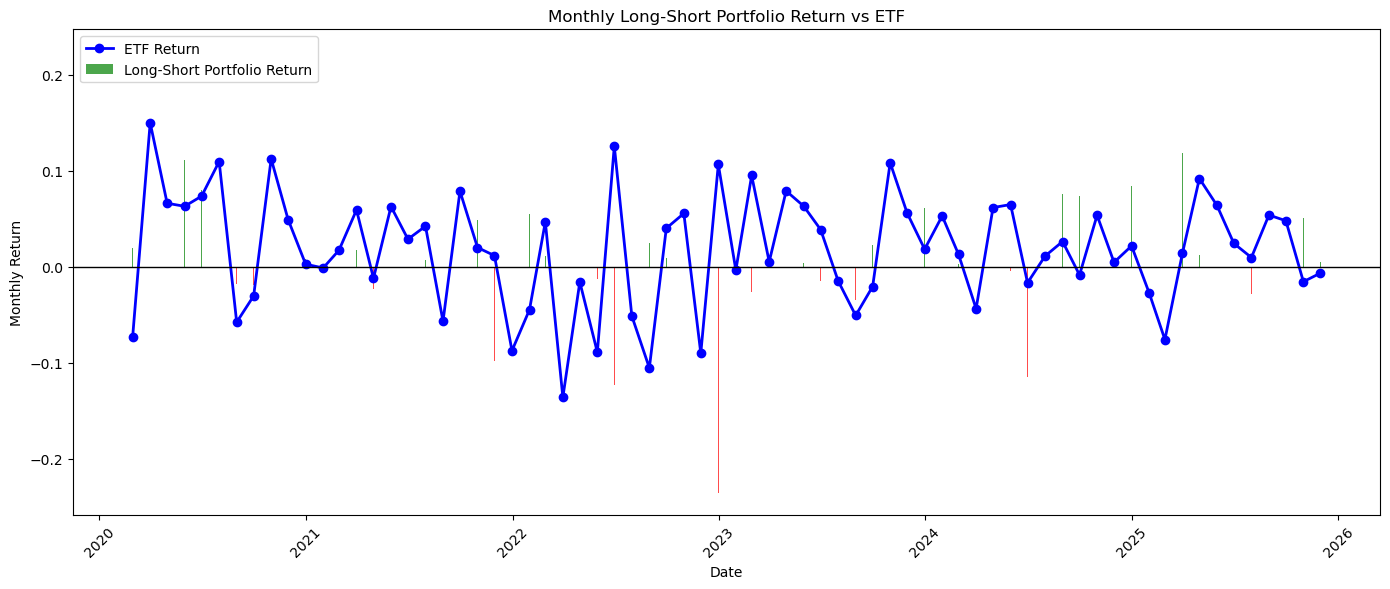

In [70]:
# Positive returns green, negative returns red
colors = np.where(backtest_df["Portfolio Return"] >= 0, "green", "red")

plt.figure(figsize=(14, 6))

plt.bar(
    backtest_df.index,
    backtest_df["Portfolio Return"],
    color=colors,
    alpha=0.7,
    label="Long-Short Portfolio Return"
)

plt.plot(
    backtest_df.index,
    backtest_df["ETF Return"],
    color="blue",
    marker="o",
    linewidth=2,
    label="ETF Return"
)

plt.axhline(0, color="black", linewidth=1)

plt.title("Monthly Long-Short Portfolio Return vs ETF")
plt.xlabel("Date")
plt.ylabel("Monthly Return")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Step 8: Chart:

### 2. Monthly return for long picks vs short picks vs ETF


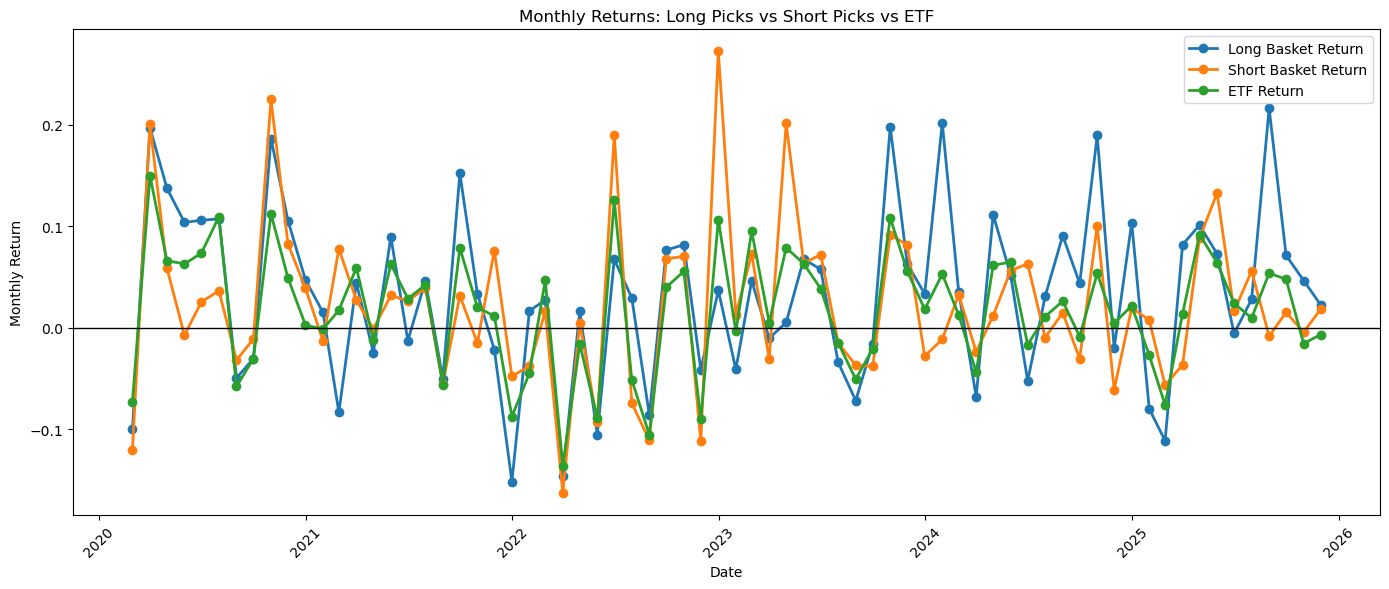

In [71]:
plt.figure(figsize=(14, 6))

plt.plot(
    backtest_df.index,
    backtest_df["Long Return"],
    marker="o",
    linewidth=2,
    label="Long Basket Return"
)

plt.plot(
    backtest_df.index,
    backtest_df["Short Return"],
    marker="o",
    linewidth=2,
    label="Short Basket Return"
)

plt.plot(
    backtest_df.index,
    backtest_df["ETF Return"],
    marker="o",
    linewidth=2,
    label="ETF Return"
)

plt.axhline(0, color="black", linewidth=1)

plt.title("Monthly Returns: Long Picks vs Short Picks vs ETF")
plt.xlabel("Date")
plt.ylabel("Monthly Return")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Step 8: Chart:

### 3. Cumulative portfolio return vs ETF

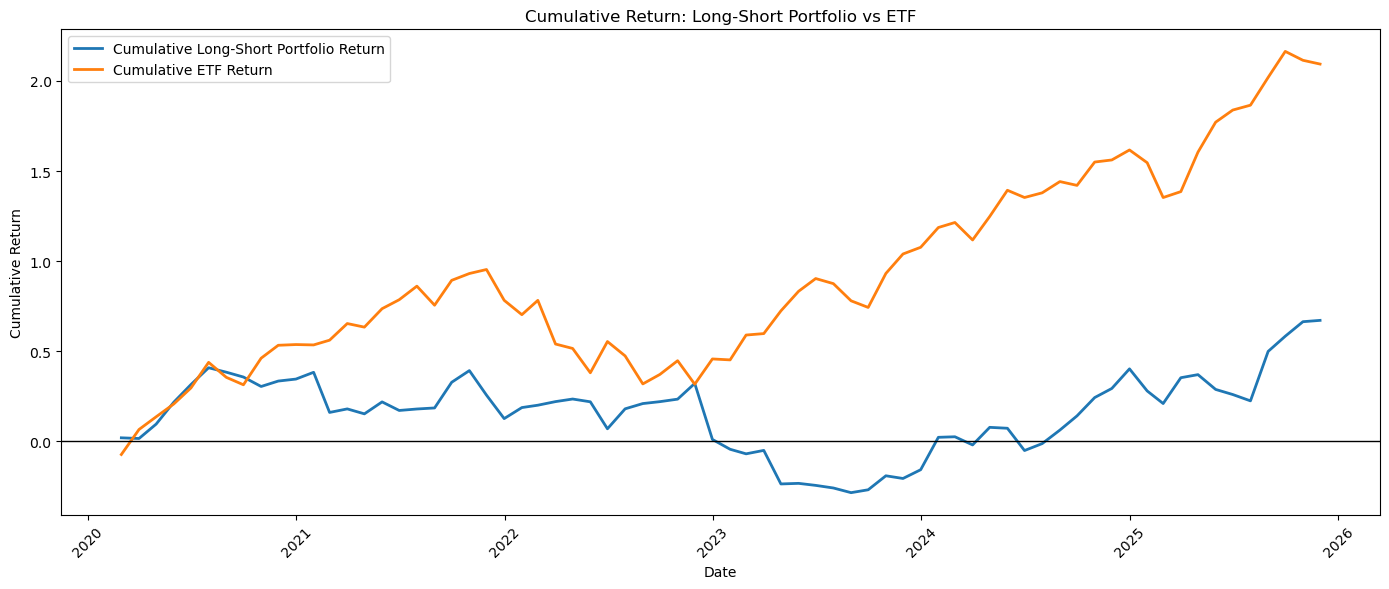

In [72]:
plt.figure(figsize=(14, 6))

plt.plot(
    backtest_df.index,
    backtest_df["Cumulative Portfolio Return"],
    linewidth=2,
    label="Cumulative Long-Short Portfolio Return"
)

plt.plot(
    backtest_df.index,
    backtest_df["Cumulative ETF Return"],
    linewidth=2,
    label="Cumulative ETF Return"
)

plt.axhline(0, color="black", linewidth=1)

plt.title("Cumulative Return: Long-Short Portfolio vs ETF")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [73]:
# Extra credit par

In [74]:
def monte_carlo_optimize_weights(returns_window, rf_annual=0.03, periods_per_year=12, 
                                 n_portfolios=50000, objective="max_sharpe", seed=42):
    """
    Monte Carlo portfolio optimizer.
    
    returns_window: historical monthly returns for selected stocks
    objective: "max_sharpe" or "min_vol"
    """

    returns_window = returns_window.dropna(axis=1)

    if returns_window.shape[1] == 0:
        return None

    tickers = returns_window.columns
    k = len(tickers)

    mu_annual = returns_window.mean() * periods_per_year
    cov_annual = returns_window.cov() * periods_per_year

    rng = np.random.default_rng(seed)

    results = []

    for _ in range(n_portfolios):
        weights = rng.random(k)
        weights = weights / weights.sum()

        exp_return = float(np.dot(weights, mu_annual.values))
        exp_var = float(weights.T @ cov_annual.values @ weights)
        exp_vol = float(np.sqrt(exp_var))

        sharpe = (exp_return - rf_annual) / exp_vol if exp_vol > 0 else -np.inf

        results.append((exp_return, exp_vol, sharpe, *weights))

    cols = ["ret", "vol", "sharpe"] + list(tickers)
    sim_df = pd.DataFrame(results, columns=cols)

    if objective == "max_sharpe":
        best_row = sim_df.loc[sim_df["sharpe"].idxmax()]
    elif objective == "min_vol":
        best_row = sim_df.loc[sim_df["vol"].idxmin()]
    else:
        raise ValueError("objective must be 'max_sharpe' or 'min_vol'")

    best_weights = best_row[tickers].astype(float)

    return best_weights

In [75]:
lookback_months = 12
num_stocks = 15

optimized_results = []

for i, date in enumerate(combined_z_score.index):

    if i < lookback_months:
        continue

    scores = combined_z_score.loc[date].dropna()

    if len(scores) < num_stocks * 2:
        continue

    long_tickers = scores.nlargest(num_stocks).index
    short_tickers = scores.nsmallest(num_stocks).index

    historical_window = monthly_returns.iloc[i-lookback_months:i]

    long_hist = historical_window[long_tickers]
    short_hist = historical_window[short_tickers]

    long_weights = monte_carlo_optimize_weights(
        long_hist,
        rf_annual=0.03,
        periods_per_year=12,
        n_portfolios=50000,
        objective="max_sharpe",
        seed=i
    )

    short_weights = monte_carlo_optimize_weights(
        short_hist,
        rf_annual=0.03,
        periods_per_year=12,
        n_portfolios=50000,
        objective="min_vol",
        seed=i+1000
    )

    if long_weights is None or short_weights is None:
        continue

    next_returns = next_month_returns.loc[date]

    long_return = (next_returns[long_weights.index] * long_weights).sum()
    short_return = (next_returns[short_weights.index] * short_weights).sum()

    optimized_portfolio_return = long_return - short_return

    etf_return = next_month_etf_returns.loc[date]

    optimized_results.append({
        "Date": date,
        "Long Return": long_return,
        "Short Return": short_return,
        "Portfolio Return": optimized_portfolio_return,
        "ETF Return": etf_return,
        "Long Tickers": list(long_weights.index),
        "Short Tickers": list(short_weights.index),
        "Long Weights": long_weights.to_dict(),
        "Short Weights": short_weights.to_dict()
    })

optimized_backtest_df = pd.DataFrame(optimized_results).set_index("Date")

In [76]:
optimized_backtest_df[["Long Return", "Short Return", "Portfolio Return", "ETF Return"]].tail()

,Long Return,Short Return,Portfolio Return,ETF Return
Date,,,,
2025-08-31,0.199809,-0.007997,0.207806,0.053762
2025-09-30,0.052545,0.009451,0.043094,0.047804
2025-10-31,0.006636,0.034417,-0.027781,-0.015610
2025-11-30,-0.019715,-0.005310,-0.014405,-0.006699
2025-12-31,0.000000,0.000000,0.000000,NaN


In [77]:
# Summary
optimized_backtest_df[["Portfolio Return", "ETF Return"]].describe()

,Portfolio Return,ETF Return
count,71.000000,70.000000
mean,0.010136,0.018004
std,0.077645,0.059505
min,-0.184074,-0.135957
25%,-0.032436,-0.015802
50%,0.021966,0.019080
75%,0.060166,0.060913
max,0.207806,0.149738


In [78]:
# Regular vs Weight Optimized backtest comparison
pd.concat([
    backtest_df[["Portfolio Return", "ETF Return"]].rename(columns={"Portfolio Return": "Regular Portfolio Return", "ETF Return": "Regular ETF Return"}),
    optimized_backtest_df[["Portfolio Return"]].rename(columns={"Portfolio Return": "Optimized Portfolio Return"})
], axis=1).describe()

,Regular Portfolio Return,Regular ETF Return,Optimized Portfolio Return
count,70.000000,70.000000,71.000000
mean,0.010507,0.018004,0.010136
std,0.079077,0.059505,0.077645
min,-0.235194,-0.135957,-0.184074
25%,-0.022929,-0.015802,-0.032436
50%,0.011207,0.019080,0.021966
75%,0.057202,0.060913,0.060166
max,0.224089,0.149738,0.207806


In [79]:
print(type(optimized_results))

for a in optimized_results:
    print("long weights: ", a["Long Weights"], "\n", "short weights: ", a["Short Weights"])
    

<class 'list'>
long weights:  {'TSLA': 0.0008955696545462638, 'SHOP': 0.170665105783717, 'NVDA': 0.010555852223547218, 'AMD': 0.08753504340688908, 'DXCM': 0.014048945216872834, 'AAPL': 0.06249538004490326, 'LRCX': 0.033152007392250056, 'CPRT': 0.23933881115979636, 'PDD': 0.01960368357080825, 'ASML': 0.08955857191488623, 'KLAC': 0.05045067523066267, 'AMAT': 0.07855255611875288, 'LITE': 0.004041606007117558, 'ALNY': 0.07936695144057927, 'WDC': 0.05973924083467084} 
 short weights:  {'FANG': 0.07725875447573209, 'INSM': 0.0026013048348789915, 'ZS': 0.035809450761414514, 'CSCO': 0.014120467812685432, 'CTSH': 0.05230715541255063, 'KHC': 0.08946878742884948, 'NFLX': 0.029656743695156935, 'BKR': 0.0637947221819703, 'WDAY': 0.1524365933072601, 'EXC': 0.16880417313358992, 'REGN': 0.024993549219239058, 'GILD': 0.12570619295142174, 'CSX': 0.10408293829042618, 'AMZN': 0.041209751671659446, 'PANW': 0.017749414823165072}
long weights:  {'TSLA': 0.0729830253685, 'NVDA': 0.06513269911950774, 'DXCM': 0

In [80]:
optimized_backtest_df["Cumulative Portfolio Return"] = (
    1 + optimized_backtest_df["Portfolio Return"]
).cumprod() - 1

optimized_backtest_df["Cumulative ETF Return"] = (
    1 + optimized_backtest_df["ETF Return"]
).cumprod() - 1

### Optimized Charts

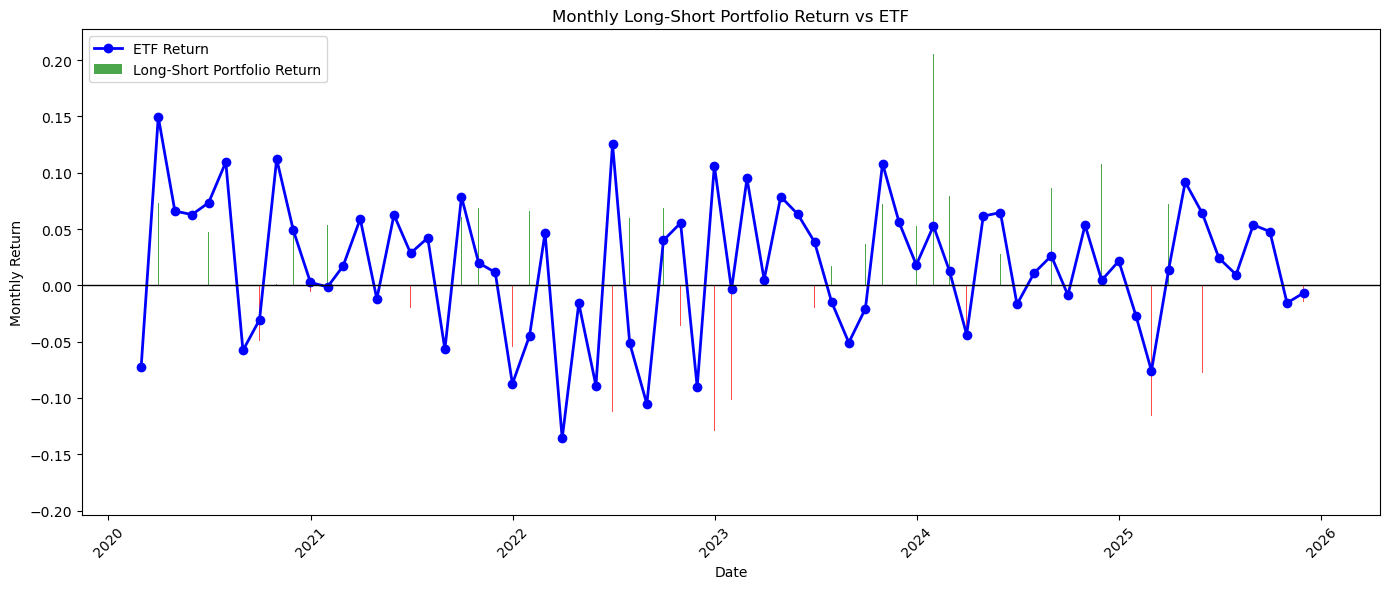

In [81]:
### chart 1

# Positive returns green, negative returns red
colors = np.where(optimized_backtest_df["Portfolio Return"] >= 0, "green", "red")

plt.figure(figsize=(14, 6))

plt.bar(
    optimized_backtest_df.index,
    optimized_backtest_df["Portfolio Return"],
    color=colors,
    alpha=0.7,
    label="Long-Short Portfolio Return"
)

plt.plot(
    optimized_backtest_df.index,
    optimized_backtest_df["ETF Return"],
    color="blue",
    marker="o",
    linewidth=2,
    label="ETF Return"
)

plt.axhline(0, color="black", linewidth=1)

plt.title("Monthly Long-Short Portfolio Return vs ETF")
plt.xlabel("Date")
plt.ylabel("Monthly Return")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


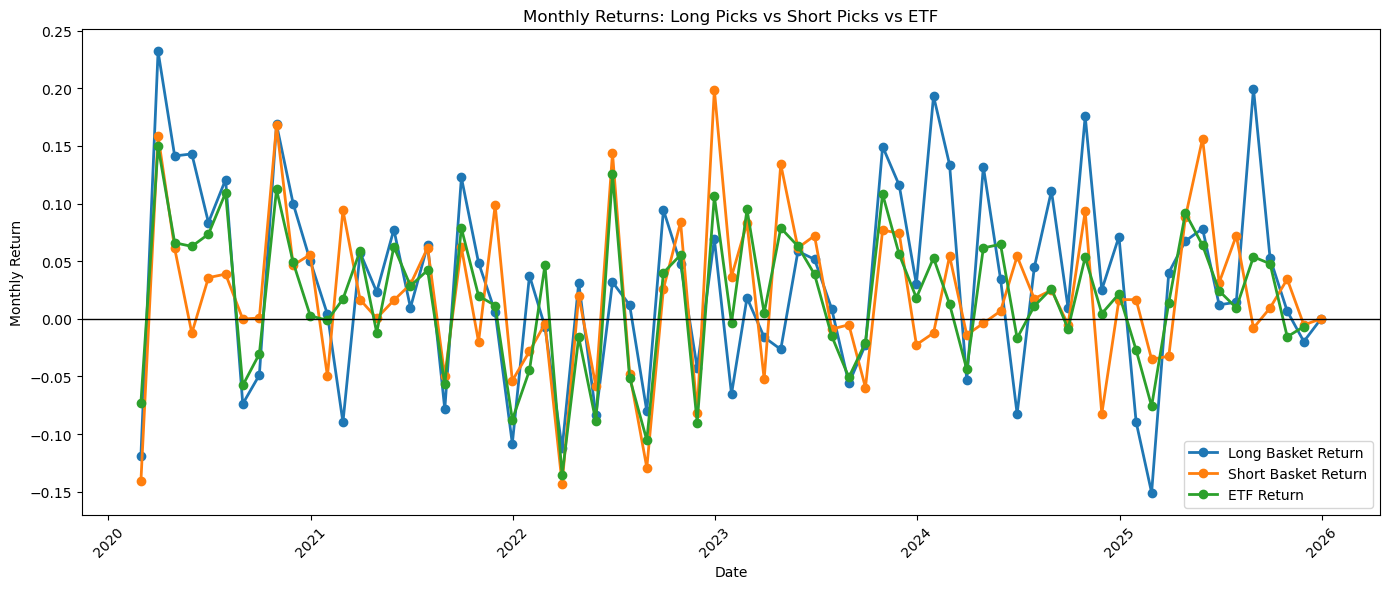

In [82]:
## chart 2

plt.figure(figsize=(14, 6))

plt.plot(
    optimized_backtest_df.index,
    optimized_backtest_df["Long Return"],
    marker="o",
    linewidth=2,
    label="Long Basket Return"
)

plt.plot(
    optimized_backtest_df.index,
    optimized_backtest_df["Short Return"],
    marker="o",
    linewidth=2,
    label="Short Basket Return"
)

plt.plot(
    optimized_backtest_df.index,
    optimized_backtest_df["ETF Return"],
    marker="o",
    linewidth=2,
    label="ETF Return"
)

plt.axhline(0, color="black", linewidth=1)

plt.title("Monthly Returns: Long Picks vs Short Picks vs ETF")
plt.xlabel("Date")
plt.ylabel("Monthly Return")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

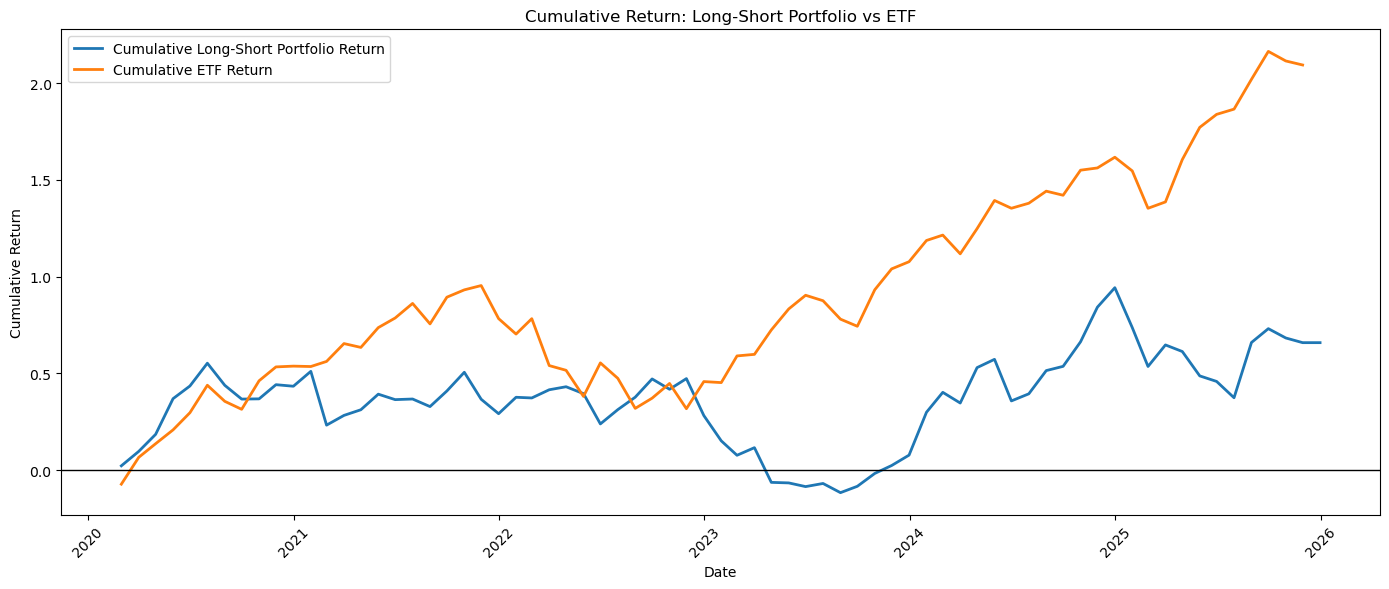

In [83]:
# chart 3
plt.figure(figsize=(14, 6))

plt.plot(
    optimized_backtest_df.index,
    optimized_backtest_df["Cumulative Portfolio Return"],
    linewidth=2,
    label="Cumulative Long-Short Portfolio Return"
)

plt.plot(
    optimized_backtest_df.index,
    optimized_backtest_df["Cumulative ETF Return"],
    linewidth=2,
    label="Cumulative ETF Return"
)

plt.axhline(0, color="black", linewidth=1)

plt.title("Cumulative Return: Long-Short Portfolio vs ETF")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()